In [1]:
# qaoa_ket_portfolio_restricted.py
#
# QAOA em Ket-LANG (4 qubits) usando COBYLA
# com mixer RESTRITO (XY) que preserva a Hamming-weight (budget fixo).

from functools import partial
from math import prod

from ket import *
from scipy.optimize import minimize
from pyqubo import Array

In [2]:
# ------------------------------
# 1) Definição do problema QUBO (portfólio simples)
# ------------------------------
def portfolio(
    exp_return: list[float],
    cov_matrix: list[list[float]],
    budget: int,
    risk: float = 0.5,
    penalty: float = 1.0,
):
    """
    Modelo de portfólio clássico em forma QUBO.
    assets[i] ∈ {0,1} indica se o ativo i entra ou não.
    """
    if not (0.0 <= risk <= 1.0):
        raise ValueError("risk deve estar entre 0 e 1")

    num_assets = len(exp_return)

    if num_assets != len(cov_matrix):
        raise ValueError(f"cov_matrix deve ser {num_assets}x{num_assets}")
    if not (0 <= budget <= num_assets):
        raise ValueError(f"budget deve estar entre 0 e {num_assets}")

    assets = Array.create("assets", shape=(num_assets,), vartype="BINARY")

    # Função objetivo (negativa, pois vamos minimizar)
    return -(
        # retorno esperado
        sum(map(prod, zip(assets, exp_return)))
        # risco (variância)
        - risk
        * sum(
            cov_matrix[i][j] * assets[i] * assets[j]
            for i in range(num_assets)
            for j in range(i + 1, num_assets)
        )
        # penalidade de orçamento (fixar número de ativos)
        - penalty * (budget - sum(assets)) ** 2
    )

In [3]:
# ------------------------------
# 2) Hamiltonianos: custo (QUBO) e mixer restrito (XY)
# ------------------------------
cost_h = qulib.ham.qubo  # igual antes


def hamming_weight_xy_mixer(qubits):
    """
    Mixer tipo XY que preserva o número de 1s (Hamming-weight).
    Atua com termos (X_i X_j + Y_i Y_j) entre pares de qubits.
    Isso garante que a evolução fica no subespaço de Hamming-weight fixo.
    """
    n = len(qubits)
    with obs():
        Hm = 0
        # versão "all-to-all" (pode trocar por anel se quiser)
        for i in range(n):
            for j in range(i + 1, n):
                Hm += X(qubits[i]) * X(qubits[j]) + Y(qubits[i]) * Y(qubits[j])
        return Hm


def qaoa_layer_restricted(model, gamma, beta, qubits):
    """
    Uma camada do QAOA: e^{-i γ H_c} seguido de e^{-i β H_m},
    onde H_m é o mixer XY restrito.
    """
    evolve(cost_h(model, qubits) * gamma)
    evolve(hamming_weight_xy_mixer(qubits) * beta)


In [4]:
# ------------------------------
# 3) Circuito QAOA completo com mixer restrito
# ------------------------------
def prepare_feasible_initial_state(qubits, budget: int):
    """
    Prepara um estado base factível com exatamente `budget` qubits em |1⟩.
    Ex.: para budget=2 e 4 qubits -> |1100⟩. Você pode customizar
    para, por exemplo, começar em |1001⟩ se quiser.
    """
    for i in range(budget):
        X(qubits[i])


def qaoa_restricted(params, model, n_qubits: int, budget: int):
    """
    QAOA com mixer restrito à Hamming-weight = budget.
    """
    p = len(params) // 2
    gammas = params[:p]
    betas = params[p:]

    process = Process()
    qubits = process.alloc(n_qubits)

    # Estado inicial factível (Hamming-weight = budget)
    prepare_feasible_initial_state(qubits, budget)

    # Camadas QAOA com mixer XY restrito
    for g, b in zip(gammas, betas):
        qaoa_layer_restricted(model, g, b, qubits)

    return qubits


def objective_restricted(params, model, n_qubits: int, budget: int):
    """
    Função objetivo clássica: <H_c> sob o circuito com mixer restrito.
    """
    qubits = qaoa_restricted(params, model, n_qubits, budget)
    return exp_value(cost_h(model, qubits)).get()


In [5]:
# ------------------------------
# 4) Main: otimização + histograma restrito
# ------------------------------
if __name__ == "__main__":
    # Dados do portfólio (4 ativos)
    cov = [
        [1.08774352e-03, 2.59532811e-04, 1.80247155e-04, 3.21724369e-04],
        [2.59532811e-04, 4.43192629e-04, 7.43211072e-05, 2.27911525e-04],
        [1.80247155e-04, 7.43211072e-05, 3.89444953e-04, 1.37915422e-04],
        [3.21724369e-04, 2.27911525e-04, 1.37915422e-04, 8.75437564e-04],
    ]

    mu = [0.31542042, 0.0571331, 0.11430001, 0.30109367]

    budget = 2         # Hamming-weight = 2 (duas ações no portfólio)
    n_qubits = 4
    p = 4              # profundidade QAOA
    x0 = [0.5] * (2 * p)

    # Modelo QUBO
    h = portfolio(exp_return=mu, cov_matrix=cov, budget=budget, risk=0.5)
    model = h.compile()

    # Otimização clássica com mixer restrito
    res = minimize(
        partial(
            objective_restricted,
            model=model,
            n_qubits=n_qubits,
            budget=budget,
        ),
        x0,
        method="COBYLA",
        options={"maxiter": 1000},
    )


 message: Return from COBYLA because the objective function has been evaluated MAXFUN times.
 success: False
  status: 3
     fun: -0.5109674381127494
       x: [ 5.679e-01  7.286e-01  2.063e+00  1.830e+00  2.850e-01
            5.515e-01  1.621e-01  4.563e-01]
    nfev: 1000
   maxcv: 0.0


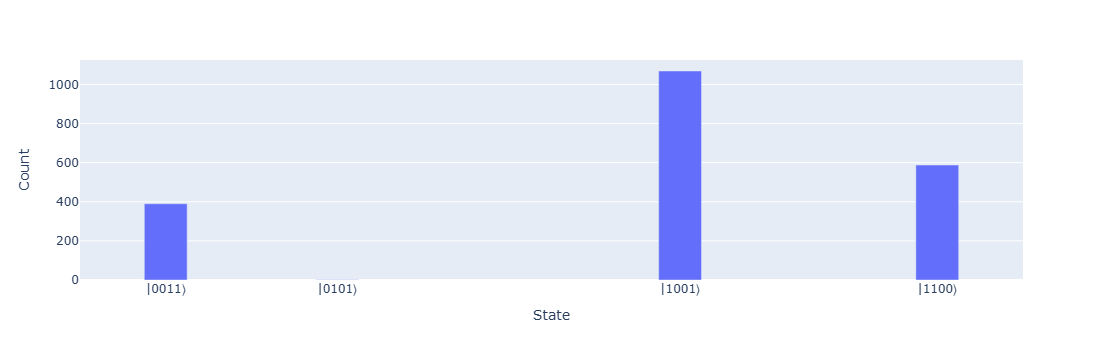

In [6]:
    print(res)  # deve ter mensagem tipo "MAXFUN times" também

    # Histograma: agora só aparecem estados com Hamming-weight = 2
    # e o estado ótimo (por ex. |1001⟩) domina a distribuição.
    sample(qaoa_restricted(res.x, model, n_qubits, budget)).histogram("bin")